# DAU Markov-modell — empirikus ráták, majd előrejelzés

**FONTOS:** a `data/user_daily_states_sample_PLACEHOLDER.csv` egyelőre
teljesen szintetikus (kézzel épített) adat, NEM valós, névtelenített
checkers.com-minta -- az utóbbi BigQuery-jóváhagyásra vár. A séma
(`user_id, day_index, state, next_state`) viszont már most a végleges --
ha megjön a valós adat, ez a notebook változtatás nélkül tovább fut.

In [1]:
import sys
sys.path.insert(0, ".")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from markov_lib import get_next_state, default_starting_state

panel = pd.read_csv("../data/user_daily_states_sample_PLACEHOLDER.csv")
panel.head()

,user_id,day_index,state,next_state
0,0,0,current_users,current_users
1,0,1,current_users,current_users
2,0,2,current_users,current_users
3,0,3,current_users,current_users
4,0,4,current_users,at_risk_wau_users


## 1. Empirikus átmeneti ráták

Egy egyszerű kereszttábla (crosstab), sorra normalizálva: minden sor egy mai
állapot, minden oszlop egy holnapi állapot, az értékek pedig empirikus
átmeneti VALÓSZÍNŰSÉGEK.

In [2]:
crosstab = pd.crosstab(panel["state"], panel["next_state"], normalize="index")
crosstab.round(3)

next_state,at_risk_90_day_users,at_risk_wau_users,current_users,dormant_users,reactivated_users,resurrected_users
state,,,,,,
at_risk_90_day_users,0.928,0.000,0.000,0.028,0.044,0.000
at_risk_wau_users,0.173,0.520,0.307,0.000,0.000,0.000
current_users,0.000,0.140,0.860,0.000,0.000,0.000
dormant_users,0.000,0.000,0.000,0.994,0.000,0.006
new_users,0.000,0.739,0.261,0.000,0.000,0.000
reactivated_users,0.000,0.411,0.589,0.000,0.000,0.000
resurrected_users,0.000,0.559,0.441,0.000,0.000,0.000


In [3]:
rates = {
    "curr": crosstab.loc["current_users", "current_users"],
    "nurr": crosstab.loc["new_users", "current_users"],
    "rurr": crosstab.loc["reactivated_users", "current_users"],
    "surr": crosstab.loc["resurrected_users", "current_users"],
    "iwaurr": crosstab.loc["at_risk_wau_users", "current_users"],
    "wau_loss_rate": crosstab.loc["at_risk_wau_users", "at_risk_90_day_users"],
    "reactivation_rate": crosstab.loc["at_risk_90_day_users", "reactivated_users"],
    "resurrection_rate": crosstab.loc["dormant_users", "resurrected_users"],
    "_90_day_loss_rate": crosstab.loc["at_risk_90_day_users", "dormant_users"],
}
for name, val in rates.items():
    print(f"{name:20s} = {val:.4f}")

curr                 = 0.8603
nurr                 = 0.2609
rurr                 = 0.5889
surr                 = 0.4413
iwaurr               = 0.3070
wau_loss_rate        = 0.1735
reactivation_rate    = 0.0439
resurrection_rate    = 0.0056
_90_day_loss_rate    = 0.0285


## 2. Ellenőrzés — egyetlen ráta sem lehet 0 és 1 tartományon kívül

In [4]:
assert all(0 <= v <= 1 for v in rates.values()), "Legalább egy ráta 100% fölött vagy 0 alatt van!"
print("Minden ráta (0, 1) tartományban van -- OK.")

Minden ráta (0, 1) tartományban van -- OK.


## 3. Előrejelzés a becsült rátákkal

Az új felhasználók napi száma **feltevés** (a panel mérete túl kicsi ahhoz,
hogy ebből egy valódi teljes populációra következtessünk) -- itt egy
illusztratív, kerek számot használunk. A rátákat viszont a fenti becslésből
vesszük át, VÁLTOZATLANUL, minden napra (nincs szezonalitás/trend ebben az
egyszerű változatban -- azt a `generate_dau_slide_charts.py` demonstrálja).

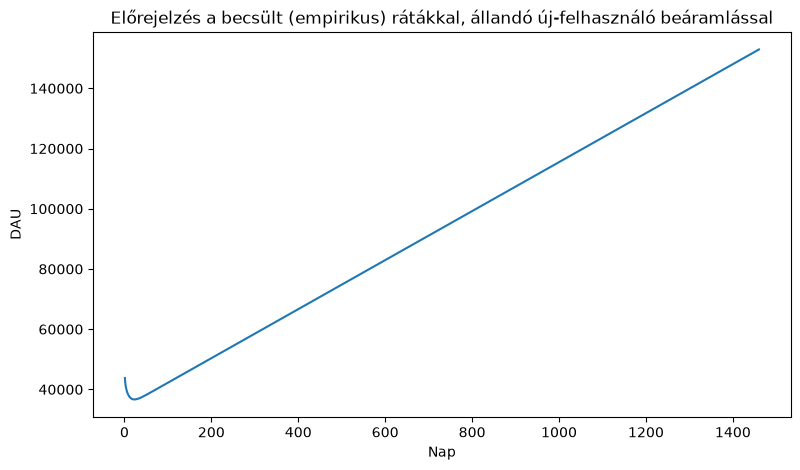

Utolsó heti növekedési ráta: 0.3738%


In [5]:
assumed_daily_new_users = 500.0
n_days = 365 * 4

trajectory_row = pd.Series({**rates, "new_users": assumed_daily_new_users})
state = default_starting_state(total=150_000.0)

history = [state]
for _ in range(n_days):
    state = get_next_state(state, trajectory_row)
    history.append(state)

hist_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hist_df["dau"].values)
ax.set_xlabel("Nap")
ax.set_ylabel("DAU")
ax.set_title("Előrejelzés a becsült (empirikus) rátákkal, állandó új-felhasználó beáramlással")
plt.show()

weekly_growth = hist_df["dau"].iloc[-1] / hist_df["dau"].iloc[-8] - 1
print(f"Utolsó heti növekedési ráta: {weekly_growth:.4%}")

**Fontos észrevétel, mielőtt tovább mennénk:** itt az új felhasználók száma
ÁLLANDÓ (nem növekszik) -- ez pontosan az az eset, amit korábban elméletben
tárgyaltunk: egy állandó bemenetű, zárt rendszer nem egy egyensúlyi
NÖVEKEDÉSI RÁTÁHOZ konvergál, hanem egy fix SZINTHEZ (ahogy a véges piacméretű
TAM-forgatókönyvben is). A heti növekedési ráta ezért idővel 0%-hoz tart --
ez itt NEM hiba, hanem pontosan a várt viselkedés.

## Ti jöttök

Mivel a rendszer egy fix SZINTHEZ tart (nem egy növekedési RÁTÁHOZ), a `curr`
javításának hatását nem az utolsó heti növekedési rátán mérjük le -- azon
alig látszik, hiszen mindkét forgatókönyv a SAJÁT egyensúlyi szintje felé
lassul, függetlenül attól, hogy az a szint alacsonyabb vagy magasabb.
Helyette hasonlítsátok össze a **végső DAU-szintet** a két forgatókönyvben.

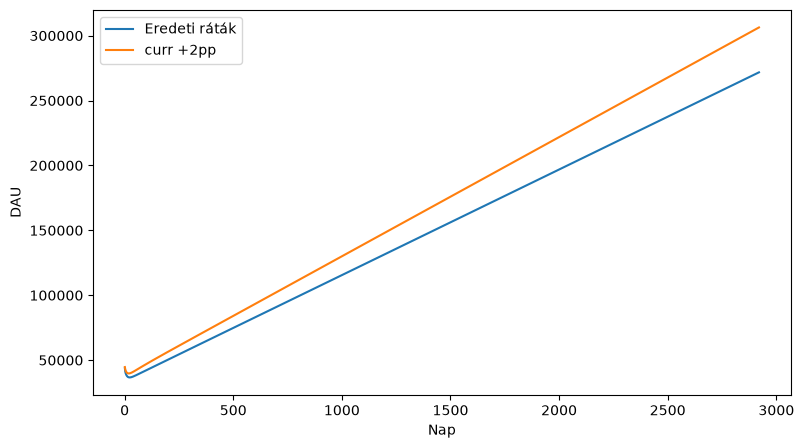

Eredeti végső DAU-szint (2920 nap után): 271,706
curr +2pp végső DAU-szint (2920 nap után): 306,293
Relatív különbség: 12.73%


In [6]:
rates_improved = dict(rates)
rates_improved["curr"] = min(rates_improved["curr"] + 0.02, 0.999)

trajectory_row_improved = pd.Series({**rates_improved, "new_users": assumed_daily_new_users})
state = default_starting_state(total=150_000.0)
history_improved = [state]
n_days_long = 365 * 8  # hosszabb horizont, hogy közelebb legyünk a konvergenciához
for _ in range(n_days_long):
    state = get_next_state(state, trajectory_row_improved)
    history_improved.append(state)
hist_improved_df = pd.DataFrame(history_improved)

# ugyanezt az eredeti ratakkal is, hosszabb horizonton, hogy fair legyen az osszehasonlitas
state = default_starting_state(total=150_000.0)
history_long = [state]
for _ in range(n_days_long):
    state = get_next_state(state, trajectory_row)
    history_long.append(state)
hist_long_df = pd.DataFrame(history_long)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hist_long_df["dau"].values, label="Eredeti ráták")
ax.plot(hist_improved_df["dau"].values, label="curr +2pp")
ax.legend()
ax.set_xlabel("Nap")
ax.set_ylabel("DAU")
plt.show()

final_base = hist_long_df["dau"].iloc[-1]
final_improved = hist_improved_df["dau"].iloc[-1]
print(f"Eredeti végső DAU-szint ({n_days_long} nap után): {final_base:,.0f}")
print(f"curr +2pp végső DAU-szint ({n_days_long} nap után): {final_improved:,.0f}")
print(f"Relatív különbség: {final_improved / final_base - 1:.2%}")